In [3]:
import numpy as np
import matplotlib.pylab as plt
import time
import math

from mgdraw_output_reader_NOVO_v03 import DetectionDataStorage

primaries_per_spawn = 1.0e7
number_of_files = 100
number_of_primaries = primaries_per_spawn * number_of_files

beam_current = 2.0 # nA

In [2]:
# Path fo FLUKA scintillator_interactions.txt-files

# Pediatric brain
main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Brain_Hv14\270_degree"

# HNC
#main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_HNC_05\AntObl_L_G80"

# Lung
#main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Lung_04\Beam_1"

# Prostate
#main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Prostate_01_2field\270"

files = {"spot1": None, "spot2": None, "spot3": None, "spot4": None, "spot5": None,
         "spot6": None, "spot7": None, "spot8": None, "spot9": None, "spot10": None}

#files = {"spot1": None}
n = 0
for file in files:
    n += 1
    PATH = main_PATH + fr"\Results_spot_{n}\scintillator_interactions"

    # Initiate DetectionDataStorage
    files[file] = DetectionDataStorage(PATH, primaries_per_spawn=primaries_per_spawn, max_files=number_of_files)

    # Load .txt-files
    files[file].load_data(mgdraw_version_8_plus=False)


Reading 105 scintillator_interactions.txt-files

c:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Skript\Plott\mgdraw_output_reader_NOVO_v03.py:544: SyntaxWarning: invalid escape sequence '\ '
  """


KeyboardInterrupt: 

In [ ]:
for file in files:
    files[file].filter_hits(beam_current=beam_current, write_hits_to_file=False)


-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 57.22 s
Total number of lines: 4587884
Number of lines kept: 1188532 (25.9%)
Number of lines rejected: 3399352 (74.1%)

-----------HIT MERGING-----------
Merging complete. Time used: 40.25 s
Overlaps found: 167367
Total number of hit histories > 10/200 keV: 681257
Number of gamma hit histories > 10 keV: 482168
Number of neutron hit histories > 200 keV: 197638
Number of combo hit histories > 200 keV: 1451


In [ ]:
# Importing post-filtered all_hits, gamma_hits and neutron_hits arrays from .txt files
from hit_txt_file_reader_v01 import collect_txt_data

files = {"spot1": None, "spot2": None, "spot3": None, "spot4": None, "spot5": None,
         "spot6": None, "spot7": None, "spot8": None, "spot9": None, "spot10": None}

# Pediatric brain
main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Brain_Hv14\270_degree"

# HNC
#main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_HNC_05\AntObl_L_G80"

# Lung
#main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Lung_04\Beam_1"

# Prostate
#main_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Prostate_01_2field\270"

m = 0
for file in files:
    m += 1

    newPath = main_PATH + rf"\Results_spot_{m}"
    print(f"Spot {m}:")
    
    # Importing gamma_hits
    print("Gamma hits")
    gamma_hits = np.array(collect_txt_data(newPath + rf"\gamma_hits.txt"))

    # Importing neutron_hits
    print("Neutron hits")
    neutron_hits = np.array(collect_txt_data(newPath + rf"\neutron_hits.txt"))

    # Importing all hits
    print("All hits")
    all_hits = np.array(collect_txt_data(newPath + rf"\all_hits.txt"))

    files[file] = [gamma_hits, neutron_hits, all_hits]


Spot 1:
Gamma hits
Neutron hits
All hits

In [5]:
ncases = gamma_hits[0]
regions = gamma_hits[12]

icodes = gamma_hits[1]

icode, counts = np.unique(icodes, return_counts=True)

print(icode)
print(counts)

[219. 221.]
[173828   1444]


## Hits per 1e7 primaries

Statistics for patient case: HNC
Mean gamma to neutron ratio
1.7136
Std in gamma to neutron ratio
0.2498
Detection rates
Gamma rates: 2.7017e-04 - 7.0667e-04 per proton, mean: 4.662838e-04 per proton
Neutron rates: 1.6988e-04 - 4.2260e-04 per proton, mean: 2.910825e-04 per proton
Total counts per scintillator, min: 35.97, max: 544.99


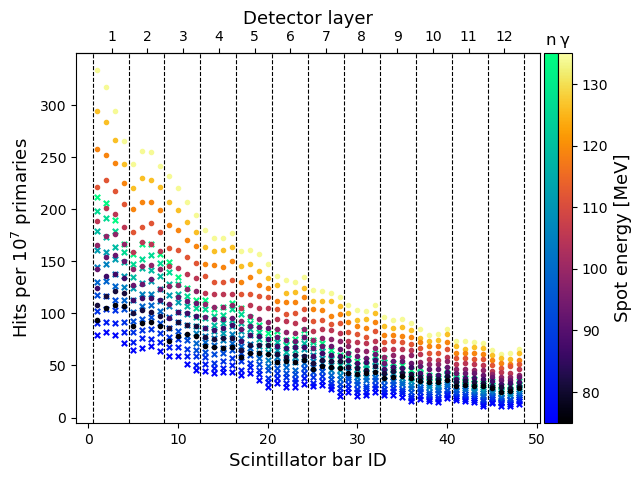

In [ ]:
from matplotlib.cm import ScalarMappable
from matplotlib.pyplot import get_cmap
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

def counts_per_primaries(counts, primaries_norm = 1e7):
    return counts / primaries_norm

primaries_norm = 1e7
primaries_norm = primaries_norm / 1e9   # If we have 1e9 primaries, then value / 1e7 primaries is the same as: value * (1e7/1e9) = 0.01 * value

# Pediatric brain
pat_name = "Brain"
energies = [120.239, 112.948, 109.551, 106.152, 99.65, 93.544, 87.635, 82.123, 76.909, 71.993]
norm = Normalize(vmin=70, vmax=125)

# HNC
#pat_name = "HNC"
#energies = [134.006, 126.327, 119.041, 111.849, 105.052, 98.649, 92.643, 86.733, 81.321, 76.106]
#norm = Normalize(vmin=75, vmax=135)

# Lung
#pat_name = "Lung"
#energies = [180.740, 169.121, 158.789, 149.843, 140.982, 132.012, 123.633, 115.546, 108.051, 100.751]
#norm = Normalize(vmin=100, vmax=180)

# Prostate
#pat_name = "Prostate"
#energies = [198, 195, 192, 189, 186, 183, 180, 177, 174, 171]
#norm = Normalize(vmin=170, vmax=200)

cmap = get_cmap("magma")
gamma_cmap = get_cmap("inferno")
neutron_cmap = get_cmap("winter")

colors = cmap(norm(energies))
gamma_colors = gamma_cmap(norm(energies))
neutron_colors = neutron_cmap(norm(energies))

regions = list(range(1, 49))

fig, ax = plt.subplots()

gamma_to_neutron_ratio = [] # 10 values (1 per energy) 
max_counts = 0
min_counts = 1e9

max_total_gamma_counts = 0
min_total_gamma_counts = 1e9
sum_total_gamma_counts = 0

max_total_neutron_counts = 0
min_total_neutron_counts = 1e9
sum_total_neutron_counts = 0

clr = -1
for file in files:
    clr += 1

    # Gammas
    gamma_regions = files[file][0][12]
    gamma_regions_counts = primaries_norm * np.array([sum(np.array(gamma_regions) == region) for region in regions])

    # Neutrons
    neutron_regions = files[file][1][12]
    neutron_regions_counts = primaries_norm * np.array([sum(np.array(neutron_regions) == region) for region in regions])

    ax.scatter(regions, gamma_regions_counts, color=gamma_colors[clr], marker=".")
    ax.scatter(regions, neutron_regions_counts, color=neutron_colors[clr], marker="x", s=15.0)

    gamma_to_neutron_ratio.append(gamma_regions_counts/neutron_regions_counts)

    # Counts (per 1e7)
    if max(gamma_regions_counts + neutron_regions_counts) > max_counts:
        max_counts = max(gamma_regions_counts + neutron_regions_counts)
    if min(gamma_regions_counts + neutron_regions_counts) <= max_counts:
        min_counts = min(gamma_regions_counts + neutron_regions_counts)


    # Max/min gamma counts
    if sum(gamma_regions_counts) > max_total_gamma_counts:
        max_total_gamma_counts = sum(gamma_regions_counts)
    if sum(gamma_regions_counts) <= min_total_gamma_counts:
        min_total_gamma_counts = sum(gamma_regions_counts)
    sum_total_gamma_counts += sum(gamma_regions_counts)

    # Max/min neutron counts
    if sum(neutron_regions_counts) > max_total_neutron_counts:
        max_total_neutron_counts = sum(neutron_regions_counts)
    if sum(neutron_regions_counts) <= min_total_neutron_counts:
        min_total_neutron_counts = sum(neutron_regions_counts)
    sum_total_neutron_counts += sum(neutron_regions_counts)

plt.xlabel("Scintillator bar ID", fontsize=13)
#plt.xticks([])
plt.ylabel(r"Hits per $10^7$ primaries", fontsize=13)

# Plotting detector layer differentiators
for i in range(0, 13):
    #break
    plt.axvline(x=4 * i + 0.5, color="black", linestyle="--", linewidth=0.8)

def region_to_layer(n_reg):
    return 1 + np.floor((n_reg - 1) / 4)

def layer_to_region(layer):
    return 2 + ((layer - 1) * 4)

# Secondary x-axis (detector layer)
ax_top = ax.secondary_xaxis("top", functions=(region_to_layer, layer_to_region))
ax_top.set_xlabel("Detector layer", fontsize=13)
region_centers = [2.5 + 4*(i-1) for i in range(1, 13)]
ax_top.set_xticks([region_to_layer(region_center) for region_center in region_centers])

# Colormaps
divider = make_axes_locatable(ax)

cax2 = divider.append_axes("right", size="3%", pad=0.04)
cax1 = divider.append_axes("right", size="3%", pad=0.00)

sm1 = ScalarMappable(norm=norm, cmap=gamma_cmap)
sm1.set_array([])  # for older Matplotlib versions
cbar1 = plt.colorbar(sm1, cax=cax1)
cbar1.set_label("Spot energy [MeV]", fontsize=13)
cbar1.ax.set_title("γ")

sm2 = ScalarMappable(norm=norm, cmap=neutron_cmap)
sm2.set_array([])  # for older Matplotlib versions
cbar2 = plt.colorbar(sm2, cax=cax2)
cbar2.set_ticks([])
cbar2.ax.tick_params(axis="both", length=0, pad=0)
cbar2.ax.minorticks_off()
cbar2.ax.set_ylabel("")
cbar2.ax.set_title("n")

#ax.set_title("Count rates per scintillator bar for prostate", loc="center")

gamma_to_neutron_ratio = np.concatenate(gamma_to_neutron_ratio)

print(f"Statistics for patient case: {pat_name}")
print("Mean gamma to neutron ratio")
print(round(np.average(gamma_to_neutron_ratio), 4))
print("Std in gamma to neutron ratio")
print(round(np.std(gamma_to_neutron_ratio), 4))

print("Detection rates")
print(f"Gamma rates: {min_total_gamma_counts / 1e7:.4e} - {max_total_gamma_counts / 1e7:.4e} per proton, mean: {sum_total_gamma_counts / (10 * 1e7):4e} per proton")
print(f"Neutron rates: {min_total_neutron_counts / 1e7:.4e} - {max_total_neutron_counts / 1e7:.4e} per proton, mean: {sum_total_neutron_counts / (10 * 1e7):4e} per proton")
print(f"Total counts per scintillator, min: {min_counts}, max: {max_counts}")

## Count rates (kcps / nA) or (kcps)

C:\Users\sathu8821\AppData\Local\Temp\ipykernel_12816\2218761298.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("magma")
C:\Users\sathu8821\AppData\Local\Temp\ipykernel_12816\2218761298.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  gamma_cmap = get_cmap("inferno")
C:\Users\sathu8821\AppData\Local\Temp\ipykernel_12816\2218761298.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  neutron_cmap = get_cmap("winter")


Max values
131.3905
Max values
123.2315
Max values
111.436
Max values
99.738
Max values
91.551
Max values
81.606
Max values
73.289
Max values
64.9815
Max values
57.2025
Max values
50.8605
1.713604836339905
0.24980252210950687
677.451
Min value
6.94


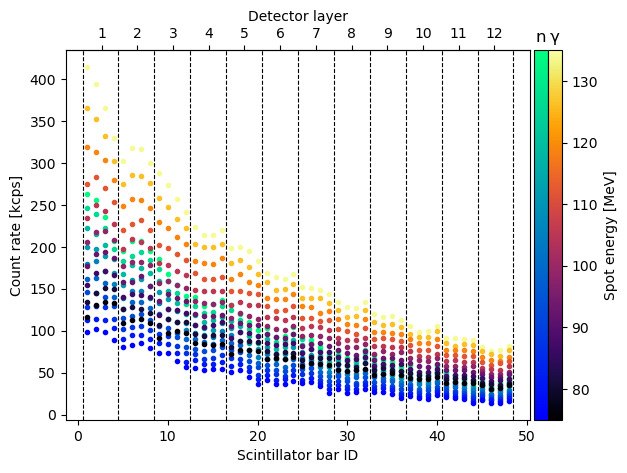

In [ ]:
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

def calculate_count_rate(counts, duration):
    """Takes in number of counts over a duration [µs] and returns the count rate [kcps]""" 
    kilo_counts = counts / 1000
    duration_in_sec = duration / 1e6    # Time in µs
    return kilo_counts / duration_in_sec

# Pediatric brain
energies = [120.239, 112.948, 109.551, 106.152, 99.65, 93.544, 87.635, 82.123, 76.909, 71.993]
norm = Normalize(vmin=70, vmax=125)

# HNC
#energies = [134.006, 126.327, 119.041, 111.849, 105.052, 98.649, 92.643, 86.733, 81.321, 76.106]
#norm = Normalize(vmin=75, vmax=135)

# Lung
#energies = [180.740, 169.121, 158.789, 149.843, 140.982, 132.012, 123.633, 115.546, 108.051, 100.751]
#norm = Normalize(vmin=100, vmax=180)

# Prostate
#energies = [198, 195, 192, 189, 186, 183, 180, 177, 174, 171]
#norm = Normalize(vmin=170, vmax=200)

cmap = get_cmap("magma")
gamma_cmap = get_cmap("inferno")
neutron_cmap = get_cmap("winter")

colors = cmap(norm(energies))
gamma_colors = gamma_cmap(norm(energies))
neutron_colors = neutron_cmap(norm(energies))

regions = list(range(1, 49))

fig, ax = plt.subplots()

gamma_to_neutron_ratio = [] # 10 values (1 per energy) 
total_count_rate_scint1 = []

clr = -1
for file in files:
    clr += 1


    # Gammas
    #gamma_regions = files[file].gamma_hits[:, 12]
    #gamma_hit_times = files[file].gamma_hits[:, 14]

    gamma_regions = files[file][0][12]
    gamma_hit_times = files[file][0][14]

    gamma_hit_times_reg = [[] for i in range(48)]
    for reg, tim in zip(gamma_regions, gamma_hit_times):
        gamma_hit_times_reg[int(reg - 1)].append(tim)

    # Neutrons
    #neutron_regions = files[file].neutron_hits[:, 12]
    #neutron_hit_times = files[file].neutron_hits[:, 14]

    neutron_regions = files[file][1][12]
    neutron_hit_times = files[file][1][14]

    neutron_hit_times_reg = [[] for i in range(48)]
    for reg, tim in zip(neutron_regions, neutron_hit_times):
        neutron_hit_times_reg[int(reg - 1)].append(tim)

    max_time = max(max(gamma_hit_times), max(neutron_hit_times))

    gamma_count_rate_reg = [round(calculate_count_rate(len(i), max_time), 3) for i in gamma_hit_times_reg]
    neutron_count_rate_reg = [round(calculate_count_rate(len(i), max_time), 3) for i in neutron_hit_times_reg]

    ax.scatter(regions, np.array(gamma_count_rate_reg), color=gamma_colors[clr], marker=".")
    ax.scatter(regions, np.array(neutron_count_rate_reg), color=neutron_colors[clr], marker=".")

    total_count_rate_scint1.append(gamma_count_rate_reg[0] + neutron_count_rate_reg[0])

    gamma_count_rate_reg = np.array(gamma_count_rate_reg)
    neutron_count_rate_reg = np.array(neutron_count_rate_reg)

    gamma_to_neutron_ratio.append(gamma_count_rate_reg/neutron_count_rate_reg)


    # TODO REMOVE
    print("Max values")
    print(0.5 * (max(neutron_count_rate_reg)))


plt.xlabel("Scintillator bar ID")
#plt.xticks([])
plt.ylabel("Count rate [kcps]")

# Plotting detector layer differentiators
for i in range(0, 13):
    #break
    plt.axvline(x=4 * i + 0.5, color="black", linestyle="--", linewidth=0.8)

def region_to_layer(n_reg):
    return 1 + np.floor((n_reg - 1) / 4)

def layer_to_region(layer):
    return 2 + ((layer - 1) * 4)

# Secondary x-axis (detector layer)
ax_top = ax.secondary_xaxis("top", functions=(region_to_layer, layer_to_region))
ax_top.set_xlabel("Detector layer")
region_centers = [2.5 + 4*(i-1) for i in range(1, 13)]
ax_top.set_xticks([region_to_layer(region_center) for region_center in region_centers])

# Colormaps
divider = make_axes_locatable(ax)

cax2 = divider.append_axes("right", size="3%", pad=0.04)
cax1 = divider.append_axes("right", size="3%", pad=0.00)

sm1 = ScalarMappable(norm=norm, cmap=gamma_cmap)
sm1.set_array([])  # for older Matplotlib versions
cbar1 = plt.colorbar(sm1, cax=cax1)
cbar1.set_label("Spot energy [MeV]")
cbar1.ax.set_title("γ")

sm2 = ScalarMappable(norm=norm, cmap=neutron_cmap)
sm2.set_array([])  # for older Matplotlib versions
cbar2 = plt.colorbar(sm2, cax=cax2)
cbar2.set_ticks([])
cbar2.ax.tick_params(axis="both", length=0, pad=0)
cbar2.ax.minorticks_off()
cbar2.ax.set_ylabel("")
cbar2.ax.set_title("n")

#ax.set_title("Count rates per scintillator bar for prostate", loc="center")

gamma_to_neutron_ratio = np.concatenate(gamma_to_neutron_ratio)
print(np.average(gamma_to_neutron_ratio))
print(np.std(gamma_to_neutron_ratio))

print(total_count_rate_scint1[0])

print("Min value")
print(min(neutron_count_rate_reg)/2)
